# STP Enrolment Credential Preprocessing QA


## Setup and Database Connection
Import required libraries and establish connection to the PSSM databases.

In [42]:

# list imported libraries
import pandas as pd
import sqlalchemy as sa
import numpy as np
import matplotlib.pyplot as plt
import yaml
from scipy.stats import ks_2samp

# open 2023 database connection
with open("../../config.yml", "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)
config23 = config["default"]["decimal2023"]
connection_string23 = (
    f"DRIVER={{{config23['driver']}}};"
    f"SERVER={config23['server']};"
    f"DATABASE={config23['database']}"
)
connection_url23 = sa.URL.create(
    "mssql+pyodbc",
    query={"odbc_connect": connection_string23},
)
engine23 = sa.create_engine(connection_url23)

# open 2025 database connection
config25 = config["default"]["decimal2025"]
connection_string25 = (
    f"DRIVER={{{config25['driver']}}};"
    f"SERVER={config25['server']};"
    f"DATABASE={config25['database']}"
)
connection_url25 = sa.URL.create(
    "mssql+pyodbc",
    query={"odbc_connect": connection_string25},
)
engine25 = sa.create_engine(connection_url25)

## Enrolment Record Type Summary
This section compares STP Enrolment Record Type distributions between the 2023 and 2025 datasets. Each enrolment record in both model runs is assigned a single Record Status code:

- 0 = Good
- 1 = Missing Student Number
- 2 = Developmental
- 3 = No PSI Transition
- 4 = Credential Only (No Enrolment Record)
- 5 = PSI_Outside_BC
- 6 = Skills Based
- 7 = Developmental CIP
- 8 = Recommendation for Certification 

A full join on RecordStatus, MinEnrolment, and FirstEnrolment compares distributions. Since the 2025 dataset spans two additional years, percentages are compared rather than raw counts to enable fair distributional comparison.

In [ ]:
# query databases, aggregate by RecordStatus, MinEnrolment, FirstEnrolment on the SQL Server for efficiency
sql23 = sa.text(
    "\
  SELECT [RecordStatus], MinEnrolment, FirstEnrolment, COUNT(*) as n\
  FROM [PSSM2023].[dbo].[STP_Enrolment_Record_Type]\
  GROUP BY RecordStatus, MinEnrolment, FirstEnrolment"
)

enrol_rec_type_23 = pd.read_sql_query(sql23, con=engine23)

sql25 = sa.text(
    "\
  SELECT [RecordStatus], is_min_enrol, is_first_enrol, COUNT(*) as n\
  FROM [PSSM2025].[IDIR\\BASHCROF].[STP_Enrolment_Record_Type_r]\
  GROUP BY RecordStatus, is_min_enrol, is_first_enrol"
)

enrol_rec_type_25 = pd.read_sql_query(sql25, con=engine25)

# join 2023 and 2025 data 
enrol_rec_type_25 = enrol_rec_type_25.rename(
    columns={"is_min_enrol": "MinEnrolment", "is_first_enrol": "FirstEnrolment"}
)

join_keys = ["RecordStatus", "MinEnrolment", "FirstEnrolment"]

# calculate proportions (as a percentage) for each record type code, first enrolment and min enrolment
enrol_rec_type_summary = (enrol_rec_type_23
    .merge(enrol_rec_type_25, how="outer", on=join_keys, suffixes=("_yr23", "_yr25"))
    .fillna(0)
    .assign(
        p_yr23=lambda d: d["n_yr23"] / d["n_yr23"].sum() * 100,
        p_yr25=lambda d: d["n_yr25"] / d["n_yr25"].sum() * 100,
    )
    .assign(diff_p=lambda d: d["p_yr23"] - d["p_yr25"])
    .sort_values(join_keys)
)

# enrol_rec_type_summary

,RecordStatus,MinEnrolment,FirstEnrolment,n_yr23,n_yr25,p_yr23,p_yr25,diff_p
0,0,0,0,7404246,8225943.0,39.465792,39.854506,-0.388714
1,0,0,1,19,0.0,0.000101,0.000000,0.000101
2,0,1,0,4676628,5226338.0,24.927161,25.321488,-0.394328
3,0,1,1,2106934,2307283.0,11.230289,11.178734,0.051555
4,2,0,0,1442630,1503360.0,7.689444,7.283745,0.405699
5,3,0,0,1043909,1096433.0,5.564199,5.312193,0.252006
6,6,0,0,2085849,2279611.0,11.117902,11.044663,0.073239
7,7,0,0,959,964.0,0.005112,0.004671,0.000441


In [ ]:
# style tabular output
enrol_rec_type_summary_styler = (
    enrol_rec_type_summary.rename(
        columns={"p_yr23": "2023(%)", "p_yr25": "2025(%)", "diff_p": "Diff(%)", "n_yr23": "2023(N)", "n_yr25": "2025(N)"}
    )
    .style.format({"2023(%)": "{:.2f}", "2025(%)": "{:.2f}", "Diff(%)": "{:.2f}", "2023(N)": "{:.0f}", "2025(N)": "{:.0f}"})
    .set_properties(
        subset=["RecordStatus", "MinEnrolment", "FirstEnrolment", "2023(N)", "2025(N)", "2023(%)", "2025(%)", "Diff(%)"],
        **{"width": "100px", "text-align": "right"},
    )  # Specific numeric overrides
    .set_properties(
        subset=["RecordStatus", "MinEnrolment", "FirstEnrolment"], **{"width": "125px"}
    )
    .set_table_styles([{"selector": "th", "props": [("text-align", "right")]}])
)

enrol_rec_type_summary_styler


,RecordStatus,MinEnrolment,FirstEnrolment,2023(N),2025(N),2023(%),2025(%),Diff(%)
0,0,0,0,7404246,8225943,39.47,39.85,-0.39
1,0,0,1,19,0,0.00,0.00,0.00
2,0,1,0,4676628,5226338,24.93,25.32,-0.39
3,0,1,1,2106934,2307283,11.23,11.18,0.05
4,2,0,0,1442630,1503360,7.69,7.28,0.41
5,3,0,0,1043909,1096433,5.56,5.31,0.25
6,6,0,0,2085849,2279611,11.12,11.04,0.07
7,7,0,0,959,964,0.01,0.00,0.00


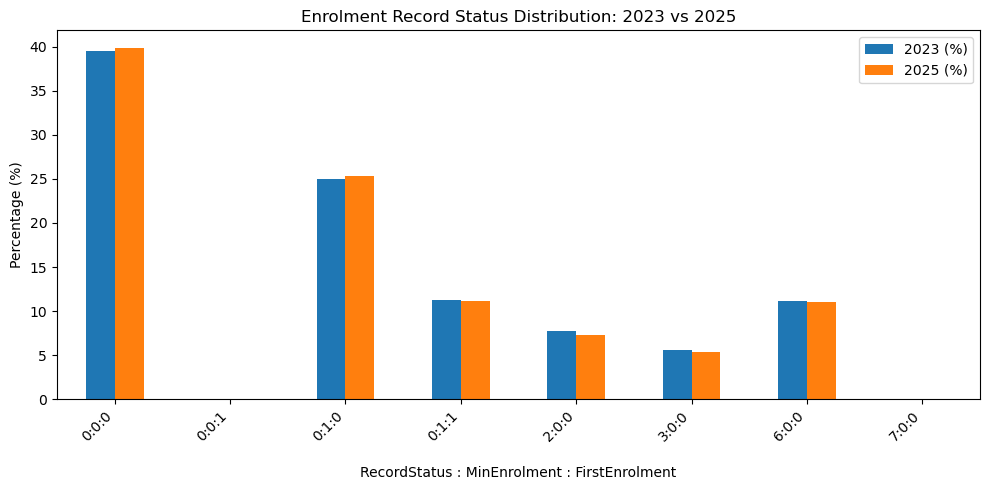

In [35]:
# create a label to indicate the various combinations
enrol_rec_type_summary["Label"] = (
    enrol_rec_type_summary["RecordStatus"].astype("Int64").astype(str).str.replace("<NA>", "?") + ":" +
    enrol_rec_type_summary["MinEnrolment"].astype("Int64").astype(str).str.replace("<NA>", "?") + ":" +
    enrol_rec_type_summary["FirstEnrolment"].astype("Int64").astype(str).str.replace("<NA>", "?")
)

plot_df = enrol_rec_type_summary.rename(columns={'p_yr23': '2023 (%)', 'p_yr25': '2025 (%)'})

# make the plot
plot_df.plot(
    x='Label', 
    y=['2023 (%)', '2025 (%)'], 
    kind='bar', 
    figsize=(10, 5), 
    title='Enrolment Record Status Distribution: 2023 vs 2025'
)
# tidy aesthetics
plt.ylabel('Percentage (%)')
plt.xlabel('\nRecordStatus : MinEnrolment : FirstEnrolment')
plt.xticks(rotation=45, ha='right') # Rotates labels so they don't overlap
plt.tight_layout()
plt.show()

## Credential Record Type Summary
This section compares STP Credential Record Type distributions between the 2023 and 2025 datasets. In both PSSM model runs, each credential record was assigned a single Record Status code using the same definitions as enrolment records (0 = Good, 1 = Missing Student Number, etc.).

Since the 2025 dataset contains two additional years of data, raw counts differ between cohorts. The code below compares percentages to enable fair distributional comparison.


In [37]:
# query databases, aggregating by RecordStatus on the SQL Server for efficiency

sql23 = sa.text(
    """
    SELECT [RecordStatus],
           COUNT(*) as n
    FROM [PSSM2023].[dbo].[STP_Credential_Record_Type]
    GROUP BY [RecordStatus]
    """
)
cred_rec_type_23 = pd.read_sql_query(sql23, con=engine23)

sql25 = sa.text(
    """
    SELECT [RecordStatus],
           COUNT(*) as n
    FROM [PSSM2025].[IDIR\\BASHCROF].[STP_Credential_Record_Type_r]
    GROUP BY [RecordStatus]
    """
)
cred_rec_type_25 = pd.read_sql_query(sql25, con=engine25)

# calculate proportions (as a percentage) for each record type code, first enrolment and min enrolment
cred_rec_type_summary = (cred_rec_type_23
    .merge(cred_rec_type_25, how="outer", on="RecordStatus", suffixes=("_yr23", "_yr25"))
    .fillna(0)
    .assign(
        p_yr23=lambda d: d["n_yr23"] / d["n_yr23"].sum() * 100,
        p_yr25=lambda d: d["n_yr25"] / d["n_yr25"].sum() * 100,
    )
    .assign(diff_p=lambda d: d["p_yr23"] - d["p_yr25"])
    .sort_values("RecordStatus")
)

cred_rec_type_summary


,RecordStatus,n_yr23,n_yr25,p_yr23,p_yr25,diff_p
0,0,1305156,1448726,95.752473,94.727351,1.025122
1,2,41138,43636,3.018080,2.853212,0.164868
2,6,5689,6030,0.417372,0.394282,0.023091
3,7,519,790,0.038076,0.051655,-0.013579
4,8,10550,30182,0.773998,1.973500,-1.199502


In [41]:

cred_rec_type_summary_styler = (
    cred_rec_type_summary
    .rename(columns={"p_yr23": "2023(%)", "p_yr25": "2025(%)", "diff_p": "Diff(%)", "n_yr23": "2023(N)", "n_yr25": "2025(N)"})
    .style
    .format({"2023(%)": "{:.2f}", "2025(%)": "{:.2f}", "Diff(%)": "{:.2f}", "2023(N)": "{:.0f}", "2025(N)": "{:.0f}"})
    .set_properties(subset=["2023(%)", "2025(%)", "Diff(%)", "2023(N)", "2025(N)", "RecordStatus"], **{"width": "100px", "text-align": "right"}) # Specific numeric overrides
    .set_properties(subset=["RecordStatus"], **{"width": "200px"})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

cred_rec_type_summary_styler

,RecordStatus,2023(N),2025(N),2023(%),2025(%),Diff(%)
0,0,1305156,1448726,95.75,94.73,1.03
1,2,41138,43636,3.02,2.85,0.16
2,6,5689,6030,0.42,0.39,0.02
3,7,519,790,0.04,0.05,-0.01
4,8,10550,30182,0.77,1.97,-1.20


## Credential Record Type Visualization
Create a bar chart comparing record type distributions between PSSM 2023 and PSSM 2025 cohorts.

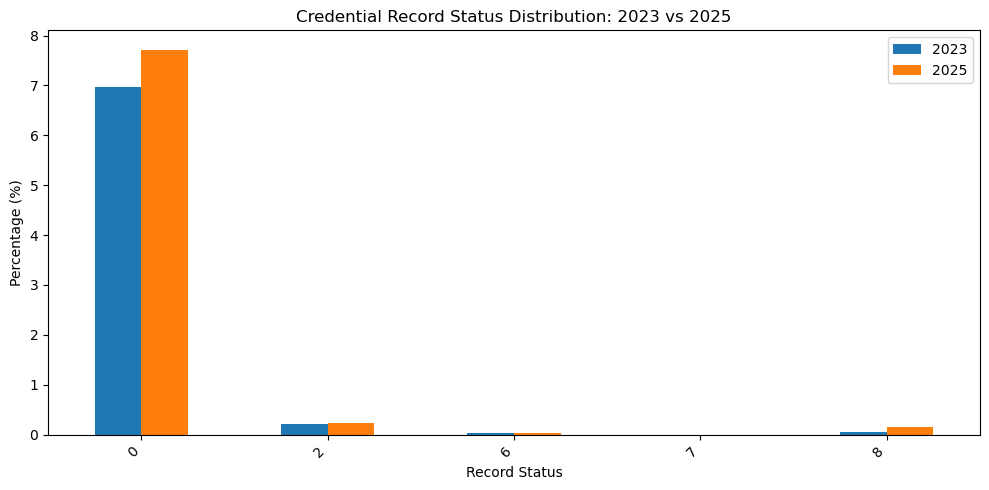

In [5]:
import matplotlib.pyplot as plt

cred_rec_type_summary["Label"] = (
    cred_rec_type_summary["RecordStatus"].astype("Int64").astype(str).str.replace("<NA>", "?")
)

plot_df = cred_rec_type_summary.rename(columns={'p.yr23': '2023 (%)', 'p.yr25': '2025 (%)'})

# make the plot
plot_df.plot(
    x='Label',
    y=['2023 (%)', '2025 (%)'],
    kind='bar',
    figsize=(10, 5),
    title='Credential Record Status Distribution: 2023 vs 2025'
)
plt.ylabel('Percentage (%)')
plt.xlabel('Record Status')
plt.xticks(rotation=45, ha='right') # Rotates labels so they don't overlap
plt.legend(['2023', '2025'])
plt.tight_layout()
plt.show()


## ECDF Plot - Age
An ECDF plot can be used to compare the 2023 and 2025 distributions of psi_birthdate_cleaned because it shows the entire empirical distribution for each age, not just summary stats.

It shows differences in:
- location: one curve would be shifted left/right
- spread: one curve would rise more slowly/quickly
- shape: curve patterns would differ across the range

At each age, x, the ECDF is the proportion of values ≤x.  Formally, for a sample $x_1, ... x_n$: 
$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} I(x_i \le x)$ where $I$ is the indicator function (for $x_i \le x$)

**Age as Reference Point**
Age is computed as of December 31 in the school-year-start year, which allows for consistent age comparison across the 2023 and 2025 cohorts. The full longitudinal span is included to verify that birthdates are imputed consistently across datasets. I *think* this approach is suitable for distribution comparison, but not ideal for more rigorous longitudinal analyses of age spread across enrolments.  

### 1: Data Preparation for Age Distribution Analysis
Query and combine enrolment data with record status = 0 from both cohorts.

In [45]:
# read all valid (RecordStatus = 0) enrolment records from 2023 data
# only include PSI_SCHOOL_YEAR and derived psi_birthdate_cleaned variables
sql23 = sa.text(
    """
SELECT
  e.PSI_SCHOOL_YEAR,
  CAST(e.psi_birthdate_cleaned AS DATE) AS psi_birthdate_cleaned
FROM [PSSM2023].[dbo].[STP_Enrolment] AS e
INNER JOIN [PSSM2023].[dbo].[STP_Enrolment_Record_Type] AS rt
  ON e.id = rt.id
WHERE rt.RecordStatus = 0;
    """
)

enrol_birthdates_23 = pd.read_sql_query(sql23, con=engine23)
enrol_birthdates_23["source"] = ("2023")

# read all valid (RecordStatus = 0) enrolment records from 2025 data
# only include PSI_SCHOOL_YEAR and derived psi_birthdate_cleaned variables
sql25 = sa.text(
    """
    SELECT
      e.PSI_SCHOOL_YEAR,
      CAST(e.psi_birthdate_cleaned AS DATE) AS psi_birthdate_cleaned
    FROM [PSSM2025].[IDIR\\BASHCROF].[stp_enrolment_r] AS e
    INNER JOIN [PSSM2025].[IDIR\\BASHCROF].[stp_enrolment_record_type_r] AS rt
      ON e.id = rt.id
    WHERE rt.RecordStatus = 0;
    """
)

enrol_birthdates_25 = pd.read_sql_query(sql25, con=engine25)
enrol_birthdates_25["source"] = ("2025")

# Combine dataframes (2023 and 2025)
cols = [
    "PSI_SCHOOL_YEAR",
    "psi_birthdate_cleaned",
    "source",
]

enrol_birthdates = pd.concat(
    [enrol_birthdates_23[cols], enrol_birthdates_25[cols]],
    ignore_index=True,
    copy=False,
)

enrol_birthdates.head(10)


,PSI_SCHOOL_YEAR,psi_birthdate_cleaned,source
0,2021/2022,2002-01-05,2023
1,2021/2022,2002-12-30,2023
2,2021/2022,2002-12-30,2023
3,2021/2022,2002-07-14,2023
4,2021/2022,2002-07-14,2023
5,2021/2022,2002-09-30,2023
6,2021/2022,2002-09-24,2023
7,2021/2022,2002-02-12,2023
8,2021/2022,2002-03-27,2023
9,2021/2022,2002-03-27,2023


### 2. Data Transformation
Combine datasets, parse dates, extract school year start, and compute age as of December 31.

In [ ]:

# Coerce date columns
enrol_birthdates["psi_birthdate_cleaned"] = enrol_birthdates["psi_birthdate_cleaned"].apply(
    pd.to_datetime, errors="coerce"
)

# Derive school-year start (first four characters of YYYY/YYYY)
enrol_birthdates["PSI_SCHOOL_YEAR_START"] = pd.to_numeric(
    enrol_birthdates["PSI_SCHOOL_YEAR"].astype("string").str.slice(0, 4),
    errors="coerce",
).astype("Int64")

# Compute age as of December 31 in the school-year-start year.
# This approach checks that birthdates are imputed consistently across years.
year_end = pd.to_datetime(
    enrol_birthdates["PSI_SCHOOL_YEAR_START"].astype("string") + "-12-31",
    errors="coerce",
)

enrol_birthdates["age"] = (year_end - enrol_birthdates["psi_birthdate_cleaned"]).dt.days.div(365.2425)

enrol_birthdates.head(5)

## Data Filtering
Applies the following validity filters to prepare data for ECDF comparison:

1. Remove rows where psi_birthdate_cleaned == 1900-01-01 (placeholder/missing dates).
2. Keep only ages in the range [0, 100] to exclude implausible values.
3. Ensure fair comparison by restricting each dataset to a 10-year lookback:
    - 2023 cohort: school years starting 2014 or later (2014–2023)
    - 2025 cohort: school years starting 2016 or later (2016–2025)

In [7]:

# Some filtering and transforming
birthdate_is_valid = enrol_birthdates["psi_birthdate_cleaned"].ne(pd.Timestamp("1900-01-01"))
age_is_valid = enrol_birthdates["age"].between(0, 100)

# include only a 10-year window
cohort_window = (
    ((enrol_birthdates["source"] == "2023") & (enrol_birthdates["PSI_SCHOOL_YEAR_START"] >= 2014))
    | ((enrol_birthdates["source"] == "2025") & (enrol_birthdates["PSI_SCHOOL_YEAR_START"] >= 2016))
)

# Make plot data
birthdate_ecdf_plot_data = (
    enrol_birthdates.loc[birthdate_is_valid & age_is_valid & cohort_window, ["source", "age"]]
    .dropna(subset=["age"])
    .copy()
)

birthdate_ecdf_plot_data.head(5)

,source,age
0,2023,19.003813
1,2023,19.003813
2,2023,19.466519
3,2023,19.466519
4,2023,19.252962


## ECDF Plot Visualization
Plot empirical cumulative distribution functions for age comparison (yellow for 2023, blue for 2025; green where overlapping).

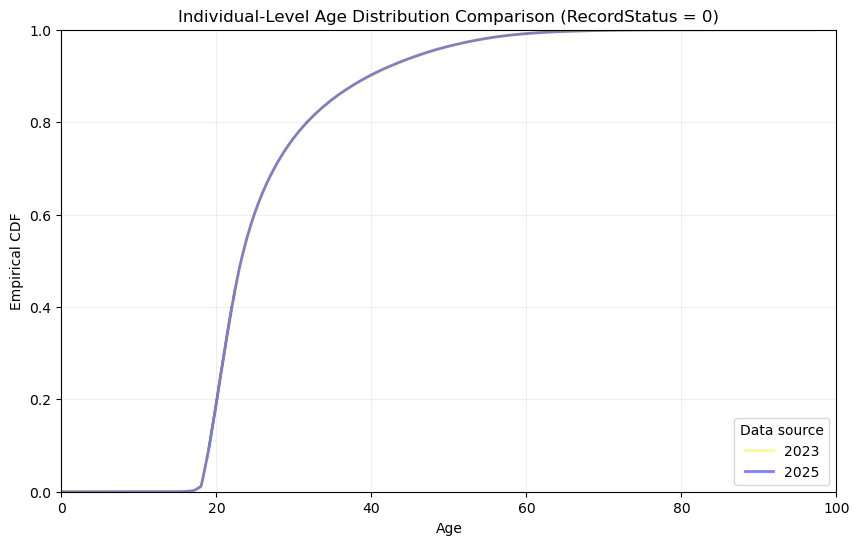

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))

source_order = ["2023", "2025"]
source_colors = {"2023": "yellow", "2025": "blue"}

# Make matplotlib plot data
for source in source_order:
    s = birthdate_ecdf_plot_data.loc[
        birthdate_ecdf_plot_data["source"] == source, "age"
    ].dropna()

   # Aggregate first: one point per unique age value
    counts = s.value_counts().sort_index()
    x = counts.index.to_numpy()
    y = counts.cumsum().to_numpy() / counts.sum()

    ax.step(x, y, where="post", linewidth=2, alpha=0.5, color=source_colors[source], label=source)

# formatting options
ax.set_title("Enrolments -  Age Distribution Comparison (RecordStatus = 0)")
ax.set_xlabel("Age")
ax.set_ylabel("Empirical CDF")
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.legend(title="Data source", loc="lower right")
ax.grid(alpha=0.2)

## Check Age Distribution Equivalence (Two-Sample Kolmogorov–Smirnov Test)

To assess whether psi_birthdate_cleaned behaves consistently across cohorts, this section compares the end-of-year age distributions for enrolment records from the prior 10 years in the 2023 and 2025 cohorts. A two-sample Kolmogorov–Smirnov (KS) test is used because it is a nonparametric method that compares entire empirical cumulative distribution functions (ECDFs), making it sensitive to differences in both distribution location and shape.

The hypotheses are:
​
- H0: the 2023 and 2025 samples are drawn from the same age distribution
- H1: the two samples are drawn from different age distributions

If H0 is not rejected, that supports the claim that psi_birthdate_cleaned has comparable distributions across cohorts. If H0 is rejected, it indicates a detectable distributional difference between cohorts.

The Kolmogorov–Smirnov statistic for a given cumulative distribution function $F(x)$ is:

$$D = sup_x |F1(x) - F2(x)|$$

Where $F1(x)$, $F2(x)$ are the empirical cumulative distribution functions for the 2023 and 2025 cohorts, respectively.  $sup_x$ is the supremum (similar to maximum) of the set of distances => $D$ takes the largest absolute difference between the two distribution functions across all $x$ values.  

$D$ is a measure of the similarity of the two age distributions; small $D$ (close to 0) indicates similar distributions, while large $D$ indicates greater differences.


In [ ]:
# create input vectors for KS test functions.  x = age (2023), y = age (2025)
age_2023 = birthdate_ecdf_plot_data.loc[lambda d: d["source"] == "2023", "age"].to_numpy()
age_2025 = birthdate_ecdf_plot_data.loc[lambda d: d["source"] == "2025", "age"].to_numpy()

# calculate and print the result
ks_result = ks_2samp(age_2023, age_2025, alternative="two-sided", method="asymp")

pd.DataFrame(
    {
        "n_2023": [age_2023.size],
        "n_2025": [age_2025.size],
        "ks_statistic": [ks_result.statistic]
    }
)

print(ks_result)

NameError: name 'birthdate_ecdf_plot_data' is not defined

### Result:

The 2025 distribution may be statistically distinguishable from 2023 because of the very large sample size, however the observed difference is negligible (D=0.005), indicating the distributions are practically equivalent. Additionally, the ECDF plots show the cummulative distribution functions for both 2023 and 2025 datasets perfectly overlap, therefore represent the same distribution.